#
# <center> Titanic Dataset Data Mining - Spring 2026
## <center> Created By: Saba Berenji

# Descriptive Summary

This dataset is obtained from a Kaggle repository called Titanic Dataset (https://www.kaggle.com/datasets/yasserh/titanic-dataset). . It provides information on Titanic passengers, consisting of 891 records, with each record containing 12 features.

Statistical analysis of the Age and Fare attributes shows that both are positively skewed, with skewness values of ~0.389 and ~4.787, respectively. The mild skewness in Age indicates a concentration on younger passengers with a tail extending toward older passengers. This is while the massive skewness in Fare demonstrates a highly non-normall distribution that is heavily influenced by extreme outliers.

Five different machine learning models were developed for this project. First, a standalone Decision Tree using the ID3 technique was built and visualized. Following this, four separate classifiers were built for comparative evaluation including aïve Bayes, K-Nearest Neighbor (KNN), AdaBoost, and a Support Vector Classifier (SVC).

A 5-fold stratified cross validation was used to divide the data into 80-20 training and testing sections to evaluate these four main models. The evaluation of the classifiers was based on accuracy, sensitivity, specificity, precision, recall, F1-score, and their confusion matrices. The final cross-validation averages revealed that the SVC model demonstrated a better performance across all performance metrics, making the the most suitable model for predicting survival on this dataset.

# Installing and importing libraries and packages

In [ ]:
# Installing the required libraries
!pip install numpy
!pip install pandas
!pip install scikit-learn
!pip install matplotlib
!pip install seaborn

In [ ]:
# Importing necessary libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn import tree
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix)
import seaborn as sns
from sklearn.preprocessing import OneHotEncoder
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import AdaBoostClassifier
from sklearn.svm import SVC

# Loading data

In [ ]:
# Load the dataset into a dataframe and print out the dataframe
titanic_df = pd.read_csv("Titanic-Dataset.csv")

In [ ]:
# Print data frame values across all columns
titanic_df

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,NaN,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,B42,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.4500,NaN,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,C148,C


In [ ]:
# Printing the size of the dataset
titanic_df.shape

(891, 12)

# Impute Missing Values

In [ ]:
# Identifying if we have missing values in the dataset
print(titanic_df.isnull().sum())

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64


<div style="background-color: lightblue; padding: 10px; color: black; font-size: 14px;">
As can be seen, the Age column has 177 missing values, which we will be finding a suitable way to impute them.
</div>

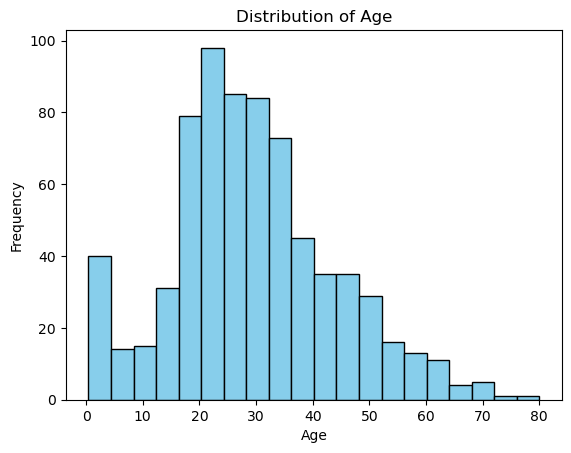

In [ ]:
# Plotting a histogram to show the distribution of the 'Age' column
plt.hist(titanic_df['Age'], bins=20, color='skyblue', edgecolor='black')
plt.xlabel('Age')
plt.ylabel('Frequency')
plt.title('Distribution of Age')

# Show the plot
plt.show()

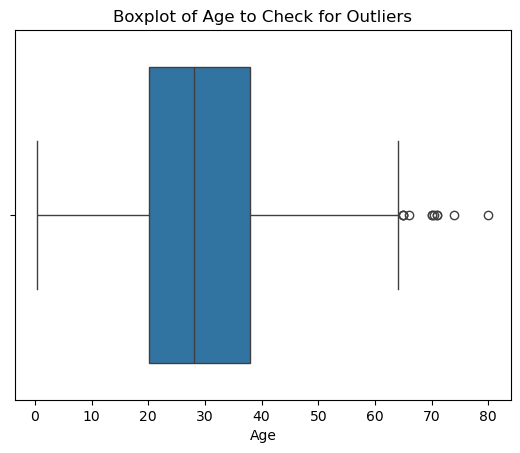

In [ ]:
# Using boxplot to check for outliers
sns.boxplot(x=titanic_df['Age'])
plt.title('Boxplot of Age to Check for Outliers')
plt.show()

In [ ]:
# Calulating the skewness of the 'Age column'
age_skewness = titanic_df['Age'].skew()
print(f"Skewness of the 'Age' column: {age_skewness}")

Skewness of the 'Age' column: 0.38910778230082704


<div style="background-color: lightblue; padding: 10px; color: black; font-size: 16px;">
    The histogram above shows that the age data is not symmetrical. It has a distinct peak in the 20s and it has a long tail stretching out to the right towards the age 80 which shows that the data is positively skewed. This can also be seen from the skewness value (~0.38) calculated for the column which is bigger than zero and means that the column does not have a completely normal distribution and is positively skewed. Additionally, the boxplot also demonstrates the skewness of this data and explicitely highlights several outliers around the age of 65 to 80. Since mean is sensitive to outliers, these older age outliers will pull the mean value upward and make it look high for the majority of the population. However, the median is resistent against outliers as it cares about the order of the data points rather than their magnitude. Therefore, 'median' is a better method of imputation for this column.
</div>

In [ ]:
# Getting the median of the 'Age' column
age_median = titanic_df['Age'].median()

# Imputing the 'Age' column with the median value
titanic_df['Age'] = titanic_df['Age'].fillna(age_median)

In [ ]:
# Identifying if we have missing values for the Age column after imputation
print(titanic_df.isnull().sum())

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age              0
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64


# Discretizing the "Age" and "Fare" columns into bins

<div style="background-color: lightblue; padding: 10px; color: black; font-size: 16px;">
    In order to determine the binning method, we have to look into the distribution of the data in the columns 'Age' and 'Fare'. We already saw how the column 'Age' had a somewhat skewed distribution and since this distribution was not normal, the equal frequency binning is suitable for this column. Now we will look into the distribution of the 'Fare' column.
</div>

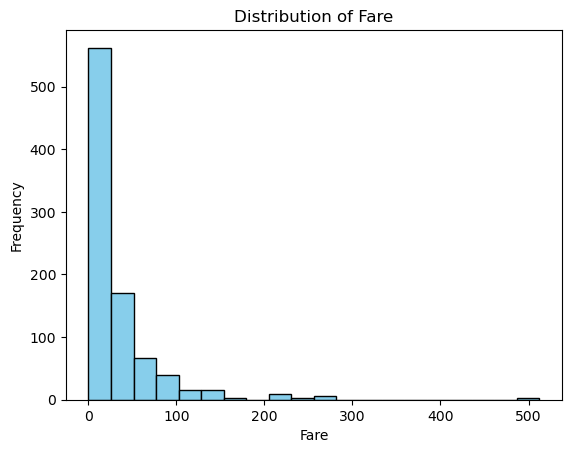

In [ ]:
# Plotting a histogram to show the distribution of the 'Fare' column
plt.hist(titanic_df['Fare'], bins=20, color='skyblue', edgecolor='black')
plt.xlabel('Fare')
plt.ylabel('Frequency')
plt.title('Distribution of Fare')

# Show the plot
plt.show()

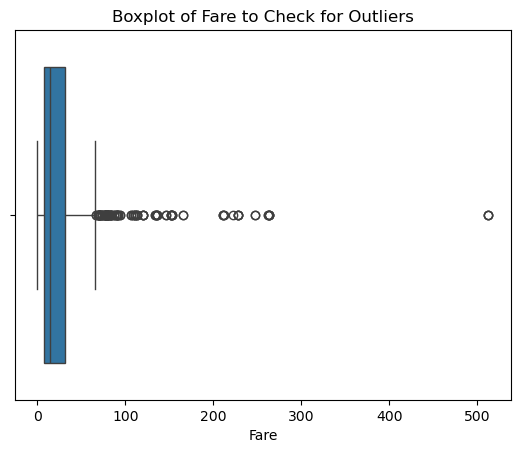

In [ ]:
# Using boxplot to check for outliers
sns.boxplot(x=titanic_df['Fare'])
plt.title('Boxplot of Fare to Check for Outliers')
plt.show()

In [ ]:
# Calulating the skewness of the 'Fare column'
fare_skewness = titanic_df['Fare'].skew()
print(f"Skewness of the 'Fare' column: {fare_skewness}")

Skewness of the 'Fare' column: 4.787316519674893


<div style="background-color: lightblue; padding: 10px; color: black; font-size: 16px;">
    As can be seen, the distribution for the 'Fare' column is heavily skewed to the right as the values are concentrated to the left of the histogram while the tail extends all the way to the right to 500. This can be seen from the skewness value calculated as well (~4.78) which also proves the positive skewness of this column. Additionally, the boxplot also shows that there are considerable number of outliers extending from about 90 to 500. Due to this skewed distribution, the equal frequency binning is the suitable binning method for this column as well.
</div>

## Bin Num Calculation

<div style="background-color: lightblue; padding: 10px; color: black; font-size: 16px;">
    The number of bins is obtained based on the Freedman-Diaconis Rule in order to draw the histograms  because it is more robust to outliers and skewed distributions.
</div>

In [ ]:
# Defining the function for the Freedman–Diaconis Rule
def fd_bin_num_caluclation(data):
    n = len(data)

    # Formula: h = 2 * IQR / n^(1/3)
    q75, q25 = np.percentile(data, [75 ,25])
    IQR = q75 - q25

    if IQR == 0:
        # If IQR is 0, a common fallback is to use the following formula using standard deviation. Reference: https://stats.stackexchange.com/questions/455237/what-to-do-when-iqr-returns-0-in-freedman-diaconis-rule#:~:text=c(al%2C%201%20%2D%20al,15%2C%202022%20at%2010:21
        bin_width = (3.49 * data.std()) / (n ** (1/3))
    else:
        bin_width = 2 * IQR / (n ** (1/3))

    # Ensuring the bin_width is not zero to avoid division by 0 error
    if bin_width == 0:
        return 1

    num_bins = int((max(data) - min(data)) / bin_width)

    return num_bins


## Binning

In [ ]:
# Defining the function for equal frequency binning
def equalFreqBinning(data, num_bins):
    # Get the name of the column dynamically
    col_name = data.name

    # Create the DataFrame using the column name
    df = pd.DataFrame(data)

    df["bin"], bin_edges = pd.qcut(df[col_name], q=num_bins, labels=False, duplicates='drop', retbins=True)   # Dropping duplicates to avoid errors when binning. source: https://pbpython.com/pandas-qcut-cut.html
    binnedData = df.groupby("bin")[col_name].apply(list).to_dict()

    return binnedData, bin_edges

In [ ]:
# Calculating the number of bins for the 'Age' and 'Fare' columns
num_bins_age = fd_bin_num_caluclation(titanic_df['Age'])
num_bins_fare = fd_bin_num_caluclation(titanic_df['Fare'])

print(f"Number of bins for Age column: {num_bins_age}")
print(f"Number of bins for Fare column: {num_bins_fare}")

Number of bins for Age column: 29
Number of bins for Fare column: 106


In [ ]:
# Perform equal-frequency binning for the 'Age' and 'Fare' columns
binned_data_age, age_bin_edges = equalFreqBinning(titanic_df['Age'], num_bins_age)
binned_data_fare, fare_bin_edges = equalFreqBinning(titanic_df['Fare'], num_bins_fare)


In [ ]:
# Display the results

for bin_num, values in binned_data_age.items():
    print(f"\nBin {bin_num} of Age column: {values}")
print("**************************************************************************")
for bin_num, values in binned_data_fare.items():
    print(f"\nBin {bin_num} of Fare column: {values}")



Bin 0 of Age column: [2.0, 4.0, 2.0, 3.0, 4.0, 0.83, 2.0, 1.0, 4.0, 1.0, 1.0, 4.0, 3.0, 2.0, 3.0, 2.0, 0.92, 2.0, 3.0, 3.0, 1.0, 1.0, 3.0, 4.0, 0.75, 2.0, 2.0, 4.0, 2.0, 0.75, 4.0, 4.0, 0.67, 1.0, 0.42, 2.0, 1.0, 0.83, 4.0, 4.0]

Bin 1 of Age column: [8.0, 7.0, 5.0, 9.0, 9.0, 9.0, 5.0, 8.0, 7.0, 5.0, 9.0, 9.0, 7.0, 9.0, 8.0, 9.0, 6.0, 6.0, 5.0, 8.0, 6.0, 9.0]

Bin 2 of Age column: [14.0, 14.0, 15.0, 14.0, 11.0, 16.0, 16.0, 14.5, 12.0, 16.0, 16.0, 16.0, 16.0, 16.0, 16.0, 16.0, 16.0, 15.0, 10.0, 14.0, 13.0, 16.0, 11.0, 16.0, 14.0, 14.0, 15.0, 11.0, 16.0, 16.0, 13.0, 16.0, 11.0, 10.0, 15.0, 16.0, 16.0, 15.0]

Bin 3 of Age column: [18.0, 18.0, 17.0, 17.0, 17.0, 18.0, 17.0, 18.0, 18.0, 18.0, 17.0, 18.0, 18.0, 18.0, 17.0, 18.0, 18.0, 17.0, 17.0, 18.0, 17.0, 17.0, 18.0, 18.0, 18.0, 18.0, 18.0, 18.0, 18.0, 18.0, 17.0, 18.0, 18.0, 17.0, 18.0, 18.0, 18.0, 17.0, 18.0]

Bin 4 of Age column: [19.0, 19.0, 19.0, 19.0, 19.0, 19.0, 19.0, 19.0, 19.0, 19.0, 19.0, 19.0, 19.0, 19.0, 19.0, 19.0, 19.0, 19.0

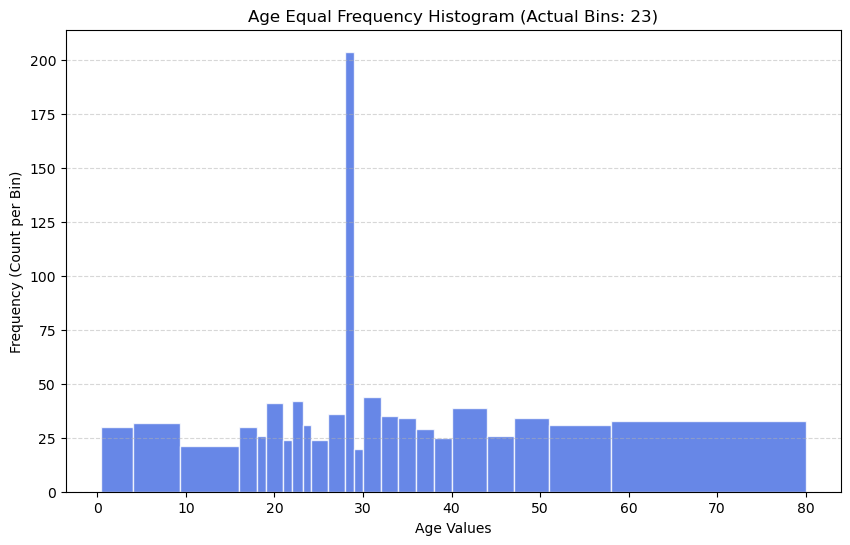

In [ ]:
# Create equal frequency histogram for age
plt.figure(figsize=(10, 6))
plt.hist(titanic_df['Age'], bins=age_bin_edges, color='royalblue', edgecolor='white', alpha=0.8)

plt.xlabel('Age Values')
plt.ylabel('Frequency (Count per Bin)')
plt.title(f'Age Equal Frequency Histogram (Actual Bins: {len(age_bin_edges)-1})') # subtracting by 1 as there is always one more edge than there are bins. age_bin_edges contains the outer boundaries too.
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.show()

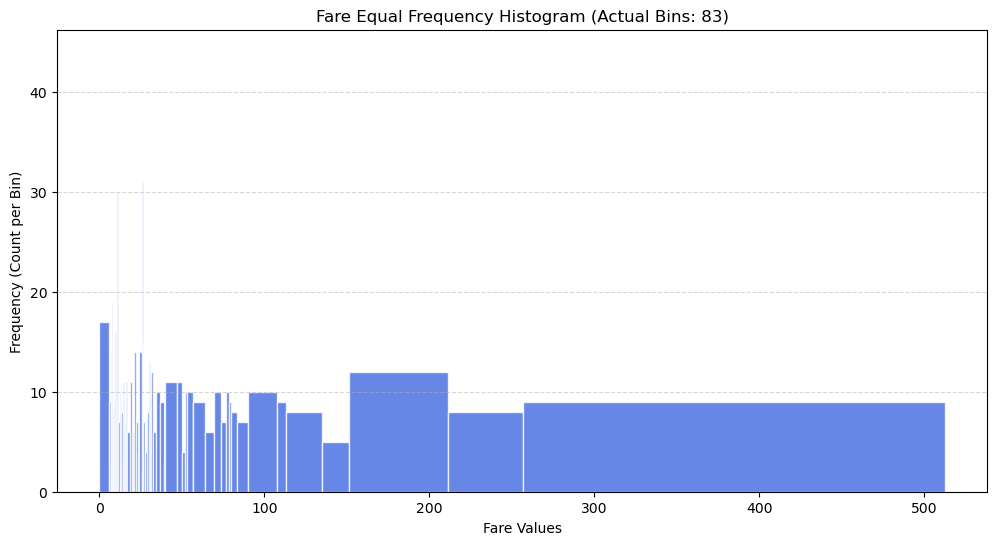

In [ ]:
# Create equal frequency histogram for fare

plt.figure(figsize=(12, 6))
plt.hist(titanic_df['Fare'], bins=fare_bin_edges, color='royalblue', edgecolor='white', alpha=0.8)

plt.xlabel('Fare Values')
plt.ylabel('Frequency (Count per Bin)')
plt.title(f'Fare Equal Frequency Histogram (Actual Bins: {len(fare_bin_edges)-1})')
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.show()

<div style="background-color: lightblue; padding: 10px; color: black; font-size: 16px;">
    You can see that the number of actual bins is smaller than the calculated number of bins based on the Freedman's rule. This is because there are duplicated values in the dataset and the 'qcut' method puts all these duplicated values inside the same bin, making the ultimate number of bins smaller than what is expected.
</div>

# Translate Nominal Categories to Integers

## Covert the 'Sex' column into integers

<div style="background-color: lightblue; padding: 10px; color: black; font-size: 16px;">
    Since there are only two values for the 'Sex' column, we would use the binary encoding where the 'male' is represented as 0 and 'female' is represented as 1.
</div>

In [ ]:
# Doing Binary Encoding on Sex column. 0 for male and 1 for female.
titanic_df["Sex"] = titanic_df["Sex"].map({
    "male": 0,
    "female": 1
})

titanic_df

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",0,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",1,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",1,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",1,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",0,35.0,0,0,373450,8.0500,NaN,S
...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",0,27.0,0,0,211536,13.0000,NaN,S
887,888,1,1,"Graham, Miss. Margaret Edith",1,19.0,0,0,112053,30.0000,B42,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",1,28.0,1,2,W./C. 6607,23.4500,NaN,S
889,890,1,1,"Behr, Mr. Karl Howell",0,26.0,0,0,111369,30.0000,C148,C


## Covert the 'Embarked' column into integers

<div style="background-color: lightblue; padding: 10px; color: black; font-size: 16px;">
    The 'Embarked' column has several distinct categories as can be seen from the dataset printed at the beginning of the file. One-hot encoding technique is suitable for this column so that each category has equal value and no ranking is involved.
</div>

### Imputing the Embarked column

<div style="background-color: lightblue; padding: 10px; color: black; font-size: 16px;">
    Previously, we saw that the Embarked column has several null values and because of this if we use the one-hot encoding technique, one of the columns added is going to be assigned for the null values since it will be considered a category of its own. Therefore, we should impute the null values of this column and since the column contains categorical values, we will use the 'mode' imputation technique.
</div>

In [ ]:
# Finding the mode of the Embarked column
mode_embarked = titanic_df['Embarked'].mode()[0]
titanic_df['Embarked'] = titanic_df['Embarked'].fillna(mode_embarked)

In [ ]:
# Identifying if we have missing values
print(titanic_df.isnull().sum())

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age              0
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         0
dtype: int64


### Perform feature encoding on the Embarked column

In [ ]:
# Using the one-hot encoding technique to encode the 'Embarked' categorical column
encoder = OneHotEncoder(sparse_output=False)

encoded = encoder.fit_transform(titanic_df[["Embarked"]])

encoded_df = pd.DataFrame(
    encoded,
    columns=encoder.get_feature_names_out(["Embarked"]),
    index=titanic_df.index
)

titanic_df = titanic_df.drop("Embarked", axis=1)
titanic_df = pd.concat([titanic_df, encoded_df], axis=1)

titanic_df

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked_C,Embarked_Q,Embarked_S
0,1,0,3,"Braund, Mr. Owen Harris",0,22.0,1,0,A/5 21171,7.2500,NaN,0.0,0.0,1.0
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",1,38.0,1,0,PC 17599,71.2833,C85,1.0,0.0,0.0
2,3,1,3,"Heikkinen, Miss. Laina",1,26.0,0,0,STON/O2. 3101282,7.9250,NaN,0.0,0.0,1.0
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",1,35.0,1,0,113803,53.1000,C123,0.0,0.0,1.0
4,5,0,3,"Allen, Mr. William Henry",0,35.0,0,0,373450,8.0500,NaN,0.0,0.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",0,27.0,0,0,211536,13.0000,NaN,0.0,0.0,1.0
887,888,1,1,"Graham, Miss. Margaret Edith",1,19.0,0,0,112053,30.0000,B42,0.0,0.0,1.0
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",1,28.0,1,2,W./C. 6607,23.4500,NaN,0.0,0.0,1.0
889,890,1,1,"Behr, Mr. Karl Howell",0,26.0,0,0,111369,30.0000,C148,1.0,0.0,0.0


# Remove text columns

<div style="background-color: lightblue; padding: 10px; color: black; font-size: 16px;">
     <p>In this step we remove text columns with no nominal or ordinal ranking. The columns that will be dropped are 'PassengerId', 'Name', 'Ticket', and 'Cabin'. The first three variables have high cardinality and are unique identifiers, meaning they possess no natural nominal or ordinal ranking and offer no predictive value. </p>
    <p>Additionally, while the 'Cabin' feature technically contains a ranking, it has an extreme amount of data missing (687 missing values out of 891 rows). This was shown at the beginning of the report when checking for null values in all of the columns. If we attempt to impute such an attribute, we would introduce significant bias into our models which justifies its removal alongside the non-ordinal text columns. </p>

</div>

In [ ]:
# Dropping PassengerId, Name, and Ticket
columns_to_drop = ['PassengerId', 'Name', 'Ticket', 'Cabin']

# Dropping columns
titanic_df = titanic_df.drop(columns=columns_to_drop, axis=1, errors='ignore')

# Printing the first five columns for verification
titanic_df.head()

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked_C,Embarked_Q,Embarked_S
0,0,3,0,22.0,1,0,7.2500,0.0,0.0,1.0
1,1,1,1,38.0,1,0,71.2833,1.0,0.0,0.0
2,1,3,1,26.0,0,0,7.9250,0.0,0.0,1.0
3,1,1,1,35.0,1,0,53.1000,0.0,0.0,1.0
4,0,3,0,35.0,0,0,8.0500,0.0,0.0,1.0


# Normalizing Numeric Columns

## Min-Max Scaling

In [ ]:
# Defining the function for min-max scaling
def min_max(data):
    min_val = np.min(data)
    max_val = np.max(data)
    normalized_data = (data - min_val) / (max_val - min_val)

    return normalized_data

### Age Min-Max Scaling

In [ ]:
# Min-max scaling for the Age column
age_data = titanic_df['Age']

normalized_data_age = min_max(age_data)

# Display the normalized data
print("Normalization of Age Data:")
print(normalized_data_age)

Normalization of Age Data:
0      0.271174
1      0.472229
2      0.321438
3      0.434531
4      0.434531
         ...   
886    0.334004
887    0.233476
888    0.346569
889    0.321438
890    0.396833
Name: Age, Length: 891, dtype: float64


### Fare Min-Max Scaling

In [ ]:
# Min-max scaling for the Fare column
fare_data = titanic_df['Fare']

normalized_data_fare = min_max(fare_data)

# Display the normalized data
print("Normalization of Fare Data:")
print(normalized_data_fare)

Normalization of Fare Data:
0      0.014151
1      0.139136
2      0.015469
3      0.103644
4      0.015713
         ...   
886    0.025374
887    0.058556
888    0.045771
889    0.058556
890    0.015127
Name: Fare, Length: 891, dtype: float64


## Standardization

In [ ]:
# Defining the function for standardization
def standardization(data):
    # Z-score normalization
    mean_val = np.mean(data)
    std_dev = np.std(data)
    normalized_data = (data - mean_val) / std_dev

    return normalized_data

### Age Standardization

In [ ]:
# Standardization for the Age column
age_data = titanic_df['Age']

standardized_data_age = standardization(age_data)

# Display the normalized data
print("Standardization of Age Data:")
print(standardized_data_age)

Standardization of Age Data:
0     -0.565736
1      0.663861
2     -0.258337
3      0.433312
4      0.433312
         ...   
886   -0.181487
887   -0.796286
888   -0.104637
889   -0.258337
890    0.202762
Name: Age, Length: 891, dtype: float64


### Fare Standardization

In [ ]:
# Standardization for the Fare column
fare_data = titanic_df['Fare']

standardized_data_fare = standardization(fare_data)

# Display the normalized data
print("Standardization of Fare Data:")
print(standardized_data_fare)

Standardization of Fare Data:
0     -0.502445
1      0.786845
2     -0.488854
3      0.420730
4     -0.486337
         ...   
886   -0.386671
887   -0.044381
888   -0.176263
889   -0.044381
890   -0.492378
Name: Fare, Length: 891, dtype: float64


## Decimal Scaling

In [ ]:
def decimal_scaling(data):
    # Find the maximum absolute value in the data
    max_abs_val = np.max(np.abs(data))

    # Calculate the minimum integer j to satisfy max(|v'_j|) < 1
    j = int(np.ceil(np.log10(max_abs_val))) if max_abs_val != 0 else 0

    # Scale the data using the formula: v_i / 10^j
    normalized_data = data / (10 ** j)

    return normalized_data

### Age Decimal Scaling

In [ ]:
# Decimal Scaling for the Age column
age_data = titanic_df['Age']

scaled_data_age = decimal_scaling(age_data)

# Display the normalized data
print("Decimal Scaling for Age Data:")
print(scaled_data_age)

Decimal Scaling for Age Data:
0      0.22
1      0.38
2      0.26
3      0.35
4      0.35
       ... 
886    0.27
887    0.19
888    0.28
889    0.26
890    0.32
Name: Age, Length: 891, dtype: float64


### Fare Decimal Scaling

In [ ]:
# Decimal Scaling for the Fare column
fare_data = titanic_df['Fare']

scaled_data_fare = decimal_scaling(fare_data)

# Display the normalized data
print("Decimal Scaling for Fare Data:")
print(scaled_data_fare)

Decimal Scaling for Fare Data:
0      0.007250
1      0.071283
2      0.007925
3      0.053100
4      0.008050
         ...   
886    0.013000
887    0.030000
888    0.023450
889    0.030000
890    0.007750
Name: Fare, Length: 891, dtype: float64


### Selecting the best method

<div style="background-color: lightblue; padding: 10px; color: black; font-size: 16px;">
    Standardization is the most appropriate transformation method over both min-max and decimal scaling methods.The exploratory analysis that was done, revealed that both of the Age and Fare variables demonstrated a right-hand skewness (particularly the Fare column). Min-max normalization relies heavily on the extreme values in the boundaries in order to scale data into a 0-1 range, while decimal scaling divides the entire feature space by a power of 10 determined only by the single absolute maximum value. Both of these methods are boundary-driven and because of that they compress a vast majority of normal data due to the extreme values and outliers in the column data. This data compression strips away the details of the data. This is while the standardization technique transforms the features based on the mean and the standard deviation that is calculated across the entire data. This technique maintains the relative distances and distribution between data points and allows the valid outliers to exist without compressing the data, making it the suitable method for this dataset.
</div>

In [ ]:
### Updating the dataframe based on the normalized data

titanic_df['Age'] = standardized_data_age
titanic_df['Fare'] = standardized_data_fare

titanic_df

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked_C,Embarked_Q,Embarked_S
0,0,3,0,-0.565736,1,0,-0.502445,0.0,0.0,1.0
1,1,1,1,0.663861,1,0,0.786845,1.0,0.0,0.0
2,1,3,1,-0.258337,0,0,-0.488854,0.0,0.0,1.0
3,1,1,1,0.433312,1,0,0.420730,0.0,0.0,1.0
4,0,3,0,0.433312,0,0,-0.486337,0.0,0.0,1.0
...,...,...,...,...,...,...,...,...,...,...
886,0,2,0,-0.181487,0,0,-0.386671,0.0,0.0,1.0
887,1,1,1,-0.796286,0,0,-0.044381,0.0,0.0,1.0
888,0,3,1,-0.104637,1,2,-0.176263,0.0,0.0,1.0
889,1,1,0,-0.258337,0,0,-0.044381,1.0,0.0,0.0


# Correlation Coefficient and Heatmap

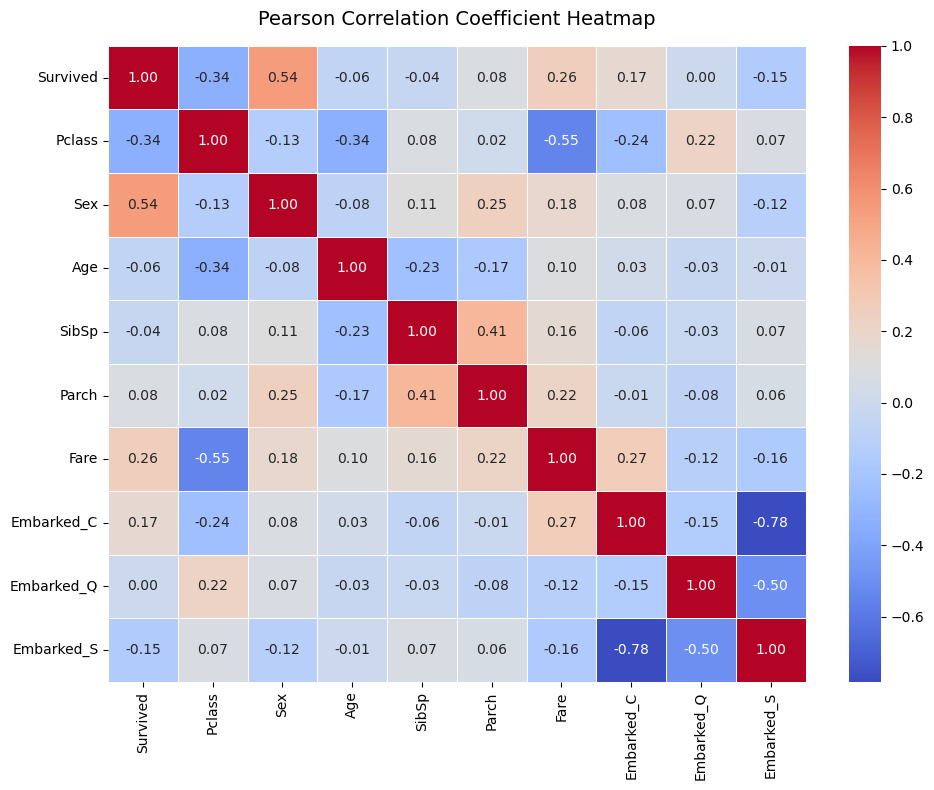

In [ ]:
# Compute Pearson's correlation coefficient matrix for all remaining attributes

corr_matrix = titanic_df.corr(method='pearson')

# Generate a heatmap visualization
plt.figure(figsize=(10, 8))
sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".2f",           # Rounds numbers to 2 decimal places
    cmap="coolwarm",
    linewidths=0.5
)

plt.title("Pearson Correlation Coefficient Heatmap", fontsize=14, pad=15)
plt.tight_layout()
plt.show()

<div style="background-color: lightblue; padding: 10px; color: black; font-size: 16px;">
    <p>Looking at the heatmap generated we can see that not a lot of variables have a positive correlation between them. The most positive correlation comes from the Survived and Sex attributes which is 0.54 and that itself is not very high to consider any of these attributes redundant. On the other hand, we can see that there is a strong negative correlation between the Embarked_C and Embarked_S variables (r = -0.78) which is because of the one-hot encoding technique that was used earlier on the Embarked feature, which created mutually exclusive categories. This could be considered somewhat redundant because a passenger could only board at one of the three ports for instance if they board from port C then we know it's not port S and if they board on port Q we still know it wasn't port S and if they don't board from either C or Q we would know it was port S, making Embarked_S column a bit redundant. However, since this does not affect the models very negatively, all three columns will be kept as is.</p>
    <p>Additionally, a moderate negative correlation exists between Pclass and Fare (r = -0.55), which shows that as passenger class tier improves (moving towards 1st class), the ticket fare increases. The relationship between metrics SibSp and Parch is also moderately positive (r = 0.41).
    Because no two unique features demonstrate a very high correlation that would indicate redundancy, no additional attributes will be removed. All the existing features demonstrate a unique variance. </p>
</div>

# Decision Tree

## Splitting the Data

In [ ]:
# Splitting the dataset into data and label/target

# Saving all the labels
titanic_df_target = titanic_df["Survived"]
# Dropping the 'PassengerId' column from the training dataset since it does not affect the outcome
titanic_df_data = titanic_df.drop("Survived",axis=1)

print("Targets:", titanic_df_target)
print("Data: ", titanic_df_data)

Targets: 0      0
1      1
2      1
3      1
4      0
      ..
886    0
887    1
888    0
889    1
890    0
Name: Survived, Length: 891, dtype: int64
Data:       Pclass  Sex       Age  SibSp  Parch      Fare  Embarked_C  Embarked_Q  \
0         3    0 -0.565736      1      0 -0.502445         0.0         0.0   
1         1    1  0.663861      1      0  0.786845         1.0         0.0   
2         3    1 -0.258337      0      0 -0.488854         0.0         0.0   
3         1    1  0.433312      1      0  0.420730         0.0         0.0   
4         3    0  0.433312      0      0 -0.486337         0.0         0.0   
..      ...  ...       ...    ...    ...       ...         ...         ...   
886       2    0 -0.181487      0      0 -0.386671         0.0         0.0   
887       1    1 -0.796286      0      0 -0.044381         0.0         0.0   
888       3    1 -0.104637      1      2 -0.176263         0.0         0.0   
889       1    0 -0.258337      0      0 -0.044381         1.0 

## Defining the Decision Tree Classifier

In [ ]:
def decisionTreeClassifier(data, labels, max_depth, splitting_criteria="entropy"):
    print(f"Decision Tree Max Depth: {max_depth}")
    dt_classifier = tree.DecisionTreeClassifier(random_state=0,max_depth=max_depth,criterion=splitting_criteria)

    # Split data into training and testing sets
    x_train, x_test, y_train, y_test = train_test_split(data, labels, test_size=0.2, random_state=42)

    # Create and train the decision tree model
    dt_classifier = dt_classifier.fit(x_train, y_train)

    # Plot the decision tree.
    tree.plot_tree(dt_classifier)

    # Make predictions on the test set
    y_pred = dt_classifier.predict(x_test)

    # Calculate accuracy using accuracy_score
    accuracy = accuracy_score(y_test, y_pred)
    print(f"Accuracy: {accuracy}")



## Training the Decision Tree and Testing it

<div style="background-color: lightblue; padding: 10px; color: black; font-size: 16px;">
    The decision tree was tested with multiple tree depths and the tree depth of 9 with the entropy splitting criteria gave the highest accuracy of 82.12%.
</div>

In [ ]:
# Defining the decision tree classifier

def decisionTreeClassifier(data, labels, max_depth, splitting_criteria="entropy"):
    print(f"Decision Tree Max Depth: {max_depth}")

    # Initialize with entropy to calculate Information Gain
    dt_classifier = tree.DecisionTreeClassifier(
        random_state=0,
        max_depth=max_depth,
        criterion=splitting_criteria
    )

    # Split data into training and testing sets
    x_train, x_test, y_train, y_test = train_test_split(data, labels, test_size=0.2, random_state=42)

    # Train the model
    dt_classifier.fit(x_train, y_train)

    # Plot the decision tree
    plt.figure(figsize=(15, 8)) # Creates a wide canvas so the boxes don't overlap
    tree.plot_tree(
        dt_classifier,
        feature_names=data.columns.tolist(),
        class_names=["Did Not Survive", "Survived"],
        max_depth=4,
        filled=True,             # Colors nodes by class dominance
        rounded=True,            # Makes the edges round
        fontsize=10              # Putting a font size that is readable
    )
    plt.title(f"Decision Tree Induction (Criterion: {splitting_criteria.upper()})", fontsize=14)
    plt.tight_layout()
    plt.show()

    # Evaluate performance
    y_pred = dt_classifier.predict(x_test)     # Make predictions on the test set

    # Calculate accuracy using accuracy_score
    accuracy = accuracy_score(y_test, y_pred)
    print(f"Test Set Accuracy: {round(accuracy * 100, 2)}%")


Decision Tree Max Depth: 9


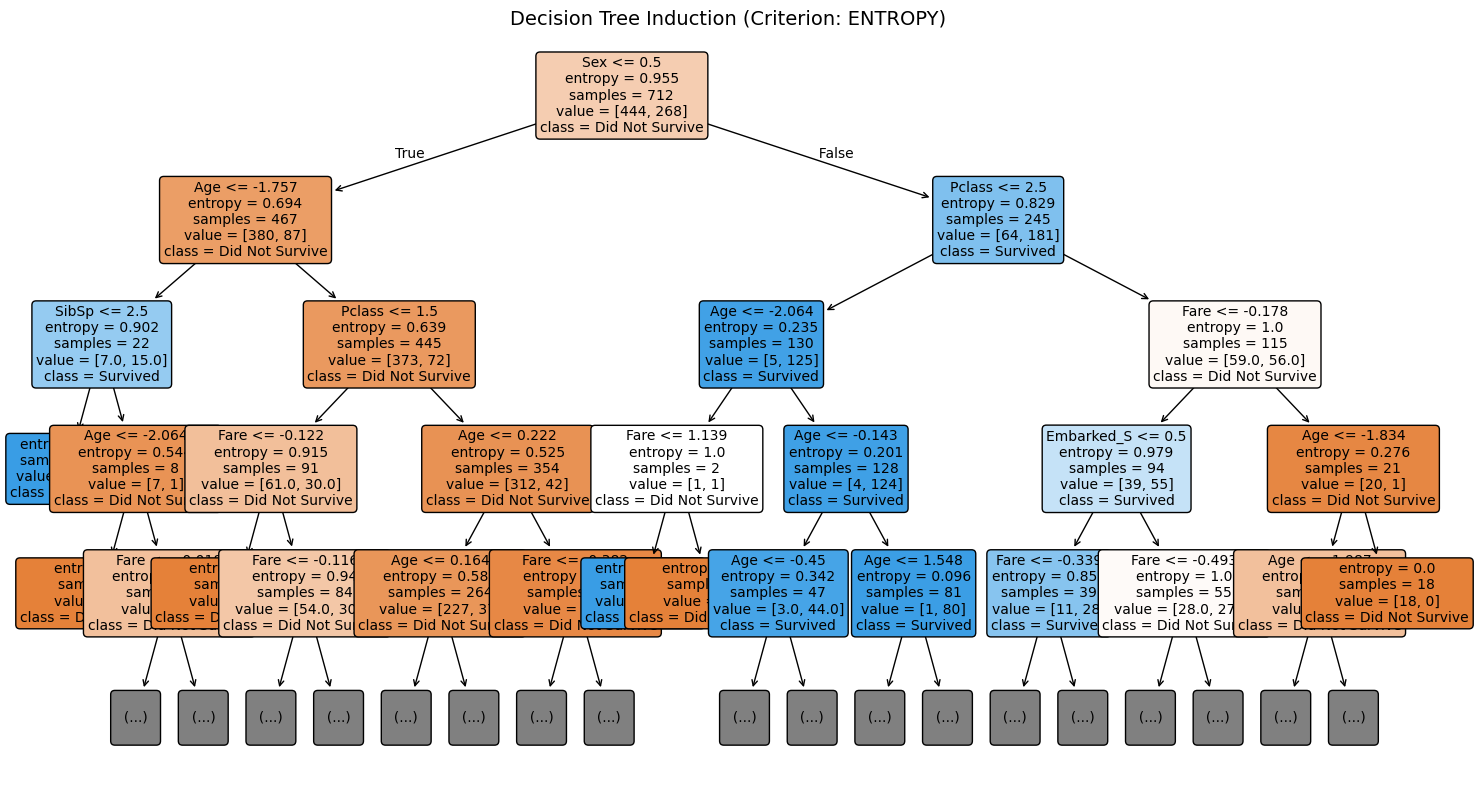

Test Set Accuracy: 82.12%


In [ ]:
decision_tree_depth = 9
decisionTreeClassifier(titanic_df_data, titanic_df_target, decision_tree_depth)

# K-fold Cross Validation

In [ ]:
# Creating 5 training and testing folds
kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Create Naïve Bayesian Classifier, K-Nearest Neighbor, AdaBoost, and SVC models

In [ ]:
# Creating a dictionary of the initialized models required along with their names
models = {
    "Naïve Bayes": GaussianNB(),
    "K-Nearest Neighbor": KNeighborsClassifier(n_neighbors=5),
    "AdaBoost": AdaBoostClassifier(n_estimators=100, random_state=42),
    "SVC": SVC(kernel='rbf', C=1.0)
}

# Train and Test the Models

In [ ]:
# Defining a function evaluating the models including training, predicting, and evaluating based on various performance metrics
def evaluateModel(model, label, x_train, y_train, x_test, y_test):

    # Train the classifier
    model.fit(x_train, y_train)

    # Make predictions on the test set
    y_pred = model.predict(x_test)

    print(f"Performance metrics for {label} model")

    # Calculate accuracy
    accuracy = accuracy_score(y_test, y_pred)
    print(f"Accuracy: {accuracy:.2f}")

    # Calculate confusion matrix
    cm = confusion_matrix(y_test, y_pred)
    tn, fp, fn, tp = cm.ravel()

    # Calculate sensitivity (recall)
    sensitivity = recall_score(y_test, y_pred)
    print(f"Sensitivity: {sensitivity:.2f}")

    # Calculate specificity
    specificity = tn / (tn + fp)
    print(f"Specificity: {specificity:.2f}")

    # Calculate precision
    precision = precision_score(y_test, y_pred)
    print(f"Precision: {precision:.2f}")

    # Calculate recall
    recall = recall_score(y_test, y_pred)
    print(f"Recall: {recall:.2f}")

    # Calculate F1 score
    f1 = f1_score(y_test, y_pred)
    print(f"F1 Score: {f1:.2f}")

    # Visualize the confusion matrix
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Survived', 'Not survived'], yticklabels=['Survived', 'Not survived'])
    plt.xlabel('Predicted labels')
    plt.ylabel('True labels')
    plt.title('Confusion Matrix')
    plt.show()

    # Returning the evaluation metrics for further calculation
    return {
        "Accuracy": accuracy,
        "Sensitivity": sensitivity,
        "Specificity": specificity,
        "Precision": precision,
        "Recall": recall,
        "F1-Score": f1
    }

In [ ]:
# Defining a function that runs the 5-fold cross-validation loop for a specific model key from the dictionary
def run_k_fold_for_model(model_key):
    model_name = model_key
    model_obj = models[model_key]

    fold_results = []
    print(f"=== Evaluating Model: {model_name} ===")

    for fold, (train_idx, test_idx) in enumerate(kf.split(X, y), 1):
        x_train, x_test = X[train_idx], X[test_idx]
        y_train, y_test = y[train_idx], y[test_idx]

        # This calls the original evaluation function and plots the matrix
        metrics = evaluateModel(model_obj, model_name, x_train, y_train, x_test, y_test)
        fold_results.append(metrics)

    # Calculate and print final averages
    mean_accuracy = sum(m["Accuracy"] for m in fold_results) / len(fold_results)
    mean_sensitivity = sum(m["Sensitivity"] for m in fold_results) / len(fold_results)
    mean_specificity = sum(m["Specificity"] for m in fold_results) / len(fold_results)
    mean_precision = sum(m["Precision"] for m in fold_results) / len(fold_results)
    mean_f1 = sum(m["F1-Score"] for m in fold_results) / len(fold_results)

    print(f"\n=== {model_name} Final Cross-Validation Averages ===")
    print(f"Mean Accuracy:    {mean_accuracy:.4f}")
    print(f"Mean Sensitivity: {mean_sensitivity:.4f}")
    print(f"Mean Specificity: {mean_specificity:.4f}")
    print(f"Mean Precision:   {mean_precision:.4f}")
    print(f"Mean F1-Score:    {mean_f1:.4f}")

In [ ]:
# Convert data to numpy arrays for reliable indexing across folds
X = titanic_df_data.values
y = titanic_df_target.values

## Naïve Bayesian Classifier Evaluation

=== Evaluating Model: Naïve Bayes ===
Performance metrics for Naïve Bayes model
Accuracy: 0.78
Sensitivity: 0.75
Specificity: 0.79
Precision: 0.69
Recall: 0.75
F1 Score: 0.72


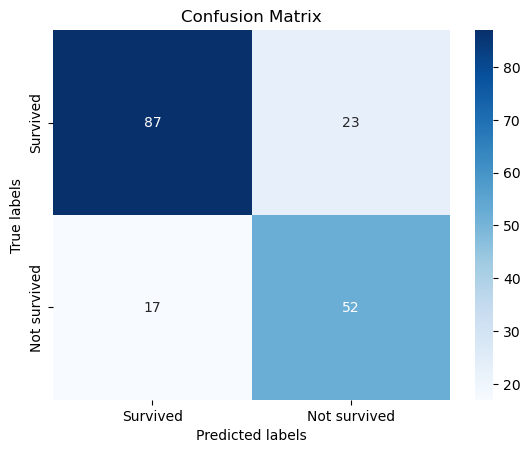

Performance metrics for Naïve Bayes model
Accuracy: 0.78
Sensitivity: 0.72
Specificity: 0.82
Precision: 0.71
Recall: 0.72
F1 Score: 0.72


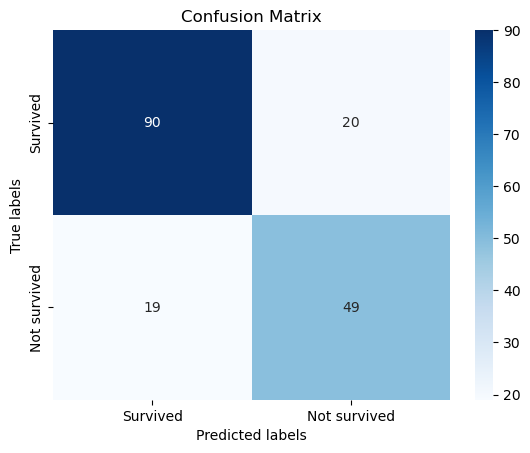

Performance metrics for Naïve Bayes model
Accuracy: 0.75
Sensitivity: 0.59
Specificity: 0.85
Precision: 0.70
Recall: 0.59
F1 Score: 0.64


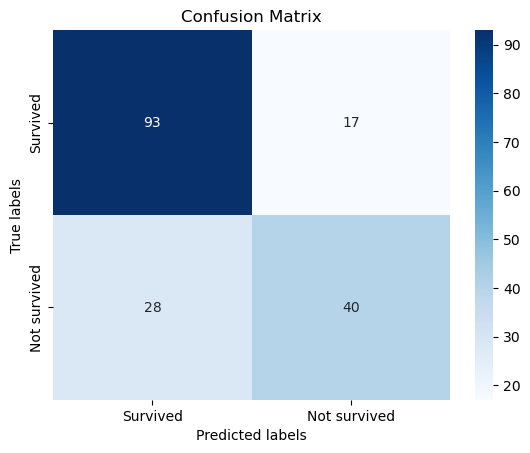

Performance metrics for Naïve Bayes model
Accuracy: 0.81
Sensitivity: 0.72
Specificity: 0.86
Precision: 0.77
Recall: 0.72
F1 Score: 0.74


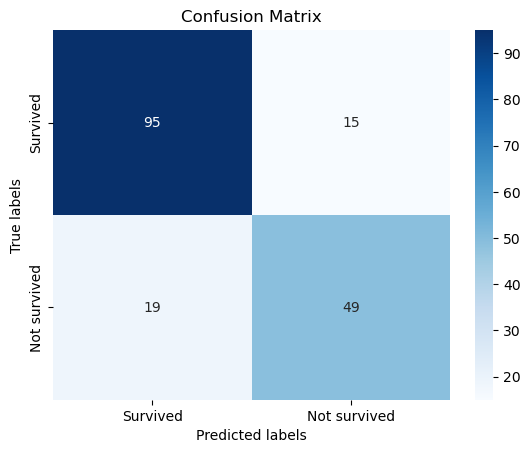

Performance metrics for Naïve Bayes model
Accuracy: 0.80
Sensitivity: 0.75
Specificity: 0.83
Precision: 0.73
Recall: 0.75
F1 Score: 0.74


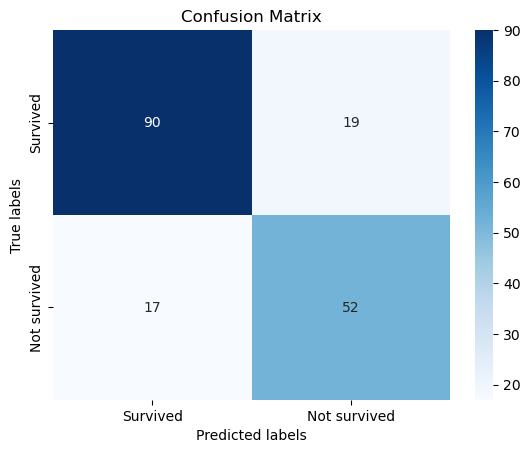


=== Naïve Bayes Final Cross-Validation Averages ===
Mean Accuracy:    0.7823
Mean Sensitivity: 0.7073
Mean Specificity: 0.8288
Mean Precision:   0.7207
Mean F1-Score:    0.7126


In [ ]:
run_k_fold_for_model("Naïve Bayes")

## K-Nearest Neighbor Classifier Evaluation

=== Evaluating Model: K-Nearest Neighbor ===
Performance metrics for K-Nearest Neighbor model
Accuracy: 0.82
Sensitivity: 0.72
Specificity: 0.88
Precision: 0.79
Recall: 0.72
F1 Score: 0.76


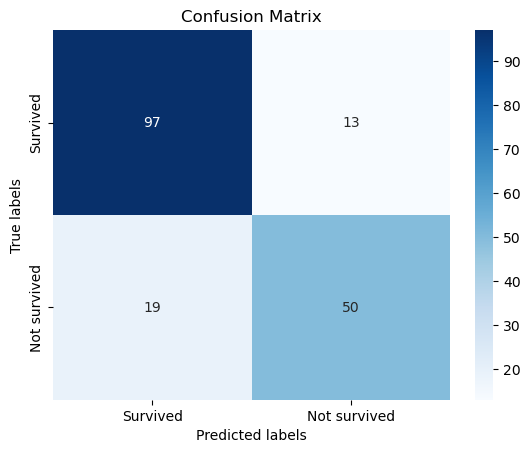

Performance metrics for K-Nearest Neighbor model
Accuracy: 0.80
Sensitivity: 0.78
Specificity: 0.82
Precision: 0.73
Recall: 0.78
F1 Score: 0.75


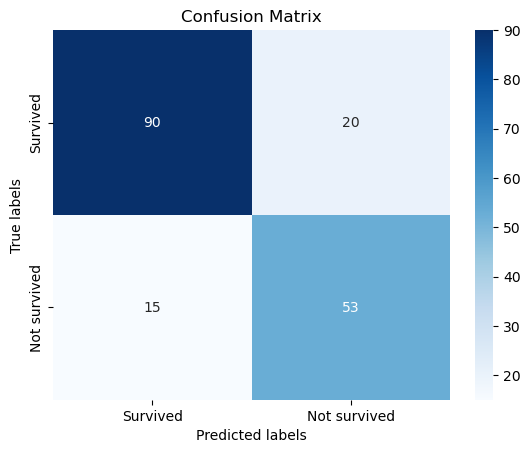

Performance metrics for K-Nearest Neighbor model
Accuracy: 0.77
Sensitivity: 0.63
Specificity: 0.85
Precision: 0.73
Recall: 0.63
F1 Score: 0.68


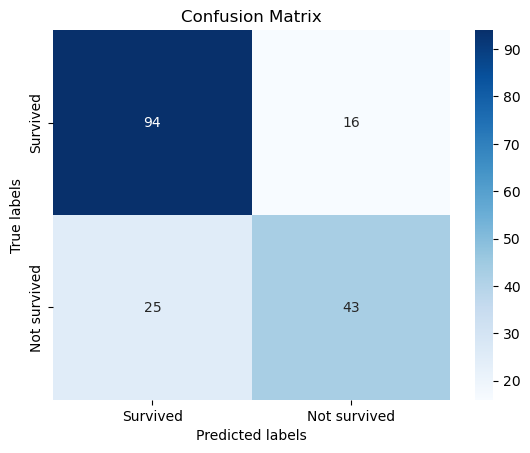

Performance metrics for K-Nearest Neighbor model
Accuracy: 0.84
Sensitivity: 0.72
Specificity: 0.91
Precision: 0.83
Recall: 0.72
F1 Score: 0.77


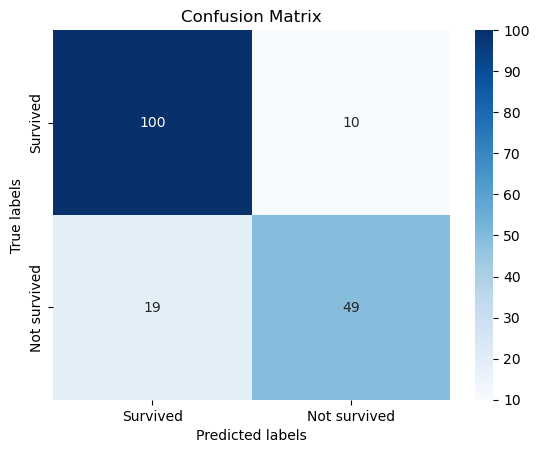

Performance metrics for K-Nearest Neighbor model
Accuracy: 0.80
Sensitivity: 0.71
Specificity: 0.86
Precision: 0.77
Recall: 0.71
F1 Score: 0.74


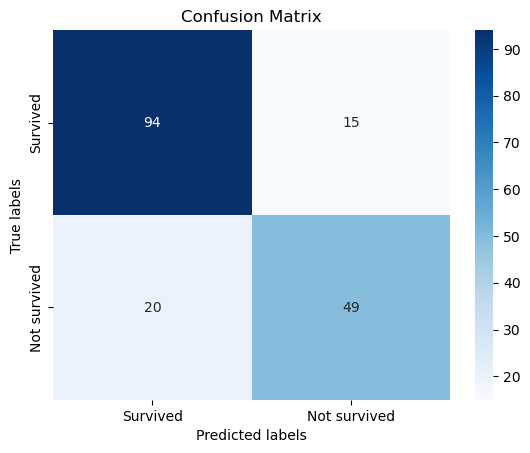


=== K-Nearest Neighbor Final Cross-Validation Averages ===
Mean Accuracy:    0.8069
Mean Sensitivity: 0.7134
Mean Specificity: 0.8652
Mean Precision:   0.7689
Mean F1-Score:    0.7390


In [ ]:
run_k_fold_for_model("K-Nearest Neighbor")

## AdaBoost Evaluation

=== Evaluating Model: AdaBoost ===
Performance metrics for AdaBoost model
Accuracy: 0.79
Sensitivity: 0.75
Specificity: 0.81
Precision: 0.71
Recall: 0.75
F1 Score: 0.73


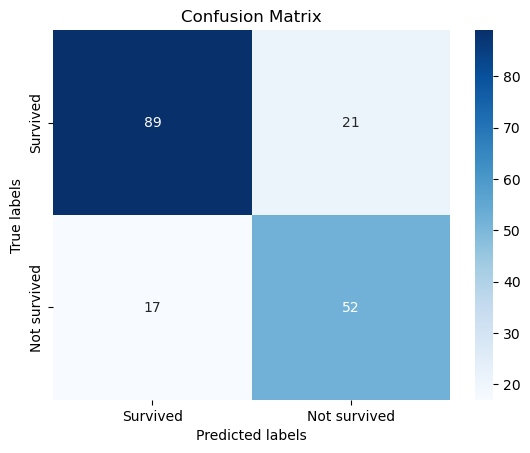

Performance metrics for AdaBoost model
Accuracy: 0.83
Sensitivity: 0.72
Specificity: 0.89
Precision: 0.80
Recall: 0.72
F1 Score: 0.76


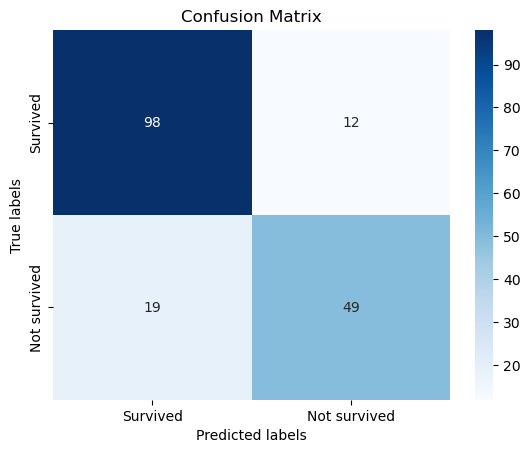

Performance metrics for AdaBoost model
Accuracy: 0.81
Sensitivity: 0.66
Specificity: 0.91
Precision: 0.82
Recall: 0.66
F1 Score: 0.73


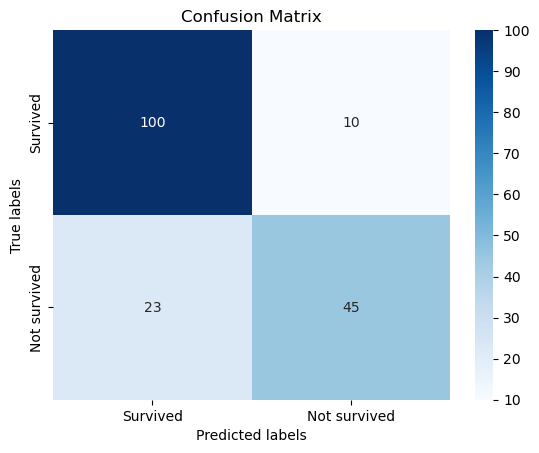

Performance metrics for AdaBoost model
Accuracy: 0.80
Sensitivity: 0.74
Specificity: 0.85
Precision: 0.75
Recall: 0.74
F1 Score: 0.74


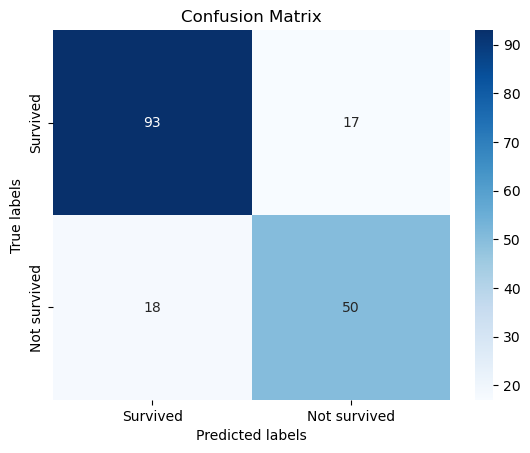

Performance metrics for AdaBoost model
Accuracy: 0.84
Sensitivity: 0.86
Specificity: 0.83
Precision: 0.76
Recall: 0.86
F1 Score: 0.80


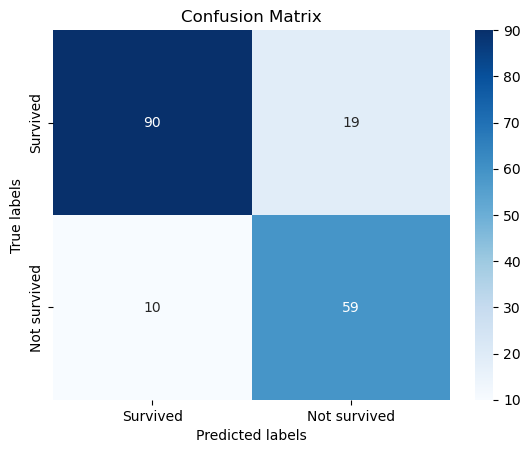


=== AdaBoost Final Cross-Validation Averages ===
Mean Accuracy:    0.8137
Mean Sensitivity: 0.7453
Mean Specificity: 0.8560
Mean Precision:   0.7673
Mean F1-Score:    0.7535


In [ ]:
run_k_fold_for_model("AdaBoost")

## SVC Classifier Evaluation

=== Evaluating Model: SVC ===
Performance metrics for SVC model
Accuracy: 0.84
Sensitivity: 0.77
Specificity: 0.89
Precision: 0.82
Recall: 0.77
F1 Score: 0.79


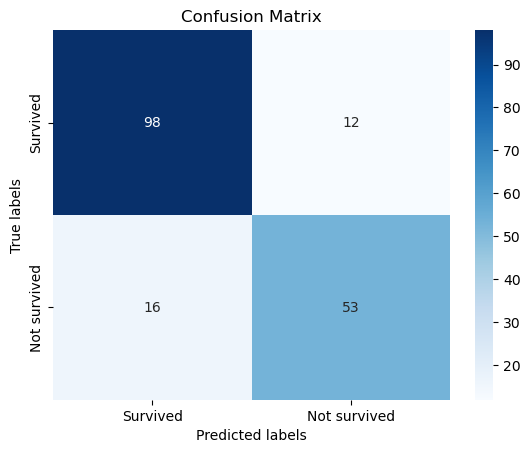

Performance metrics for SVC model
Accuracy: 0.80
Sensitivity: 0.71
Specificity: 0.86
Precision: 0.76
Recall: 0.71
F1 Score: 0.73


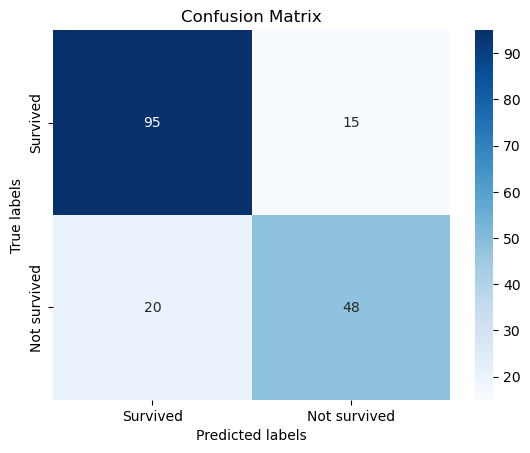

Performance metrics for SVC model
Accuracy: 0.81
Sensitivity: 0.65
Specificity: 0.91
Precision: 0.81
Recall: 0.65
F1 Score: 0.72


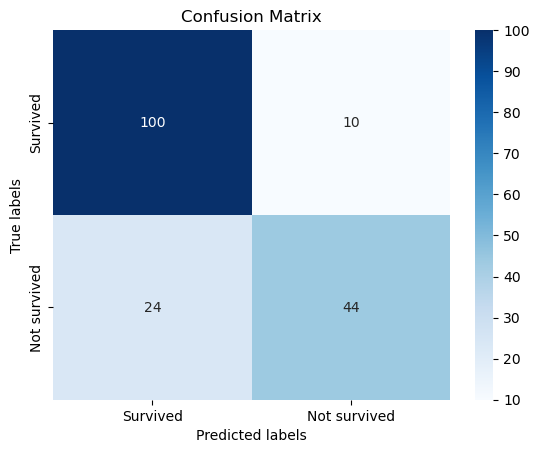

Performance metrics for SVC model
Accuracy: 0.82
Sensitivity: 0.69
Specificity: 0.90
Precision: 0.81
Recall: 0.69
F1 Score: 0.75


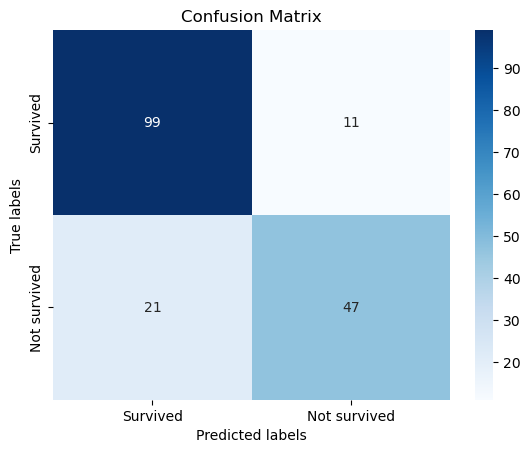

Performance metrics for SVC model
Accuracy: 0.85
Sensitivity: 0.77
Specificity: 0.90
Precision: 0.83
Recall: 0.77
F1 Score: 0.80


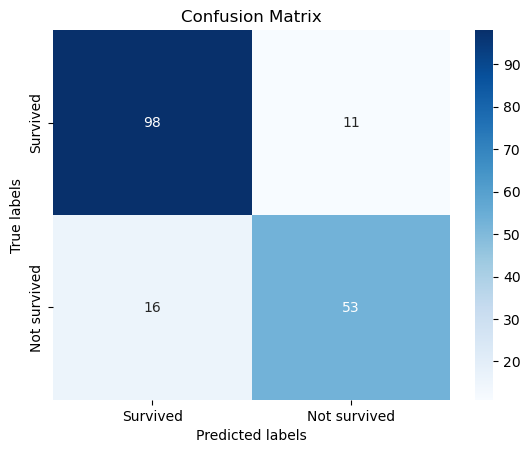


=== SVC Final Cross-Validation Averages ===
Mean Accuracy:    0.8249
Mean Sensitivity: 0.7161
Mean Specificity: 0.8925
Mean Precision:   0.8061
Mean F1-Score:    0.7576


In [ ]:
run_k_fold_for_model("SVC")

# Model Comparison

<div style="background-color: lightblue; padding: 10px; color: black; font-size: 16px;">
    
<p> Since relying on one train-test split can introduce high bias based on the random distribution of samples, a 5-fold stratified cross validation strategy was implemented. By doing this, each sample gets to act as a validation data once. All four models were trained and tested on these 5 folds and in order to show the generalized performance of each of them, their performance results over the 5-folds were used to find an arithmetic mean of the metrics. The result of this (which can be seen at the end of the output of each cell), demonstrates that the Support Vector Classifier (SVC) is the most successful model for this dataset. It excels in its performance in a majority of the performance metrics, achieving the highest overall Accuracy (82.49%) and the top F1-Score (75.76%), while performing lower than AdaBoost in the sensitivity metrics. The reason behind this can be that since AdaBoost is an ensemble boosting algorithm, it works sequentially, which means that it trains a weak decision tree, finds where the tree was wrong and forces the next tree to focus specifically on that area that it got wrong. This sequential correction led to fewer missed survivors higher sensitivity) at the expense of a lower precision.</p>

<p> The Titanic survival problem is non-linear, meaning survival depends on complex combinations of features (like being a female in a specific class or a child of a certain age). SVC handles this perfectly by using a non-linear kernel trick. This mathematically lifts our mixed-up data points into a higher-dimensional space where they easily separate, allowing the model to draw a clean boundary line (hyperplane) between survivors and non-survivors. Because our preprocessing workflow successfully standardized the continuous features (Age and Fare), SVC was able to calculate clean distances between data vectors without being skewed by raw numerical magnitudes. </p>

<p> Additionally, AdaBoost and KNN performed very close, while Naïve Bayes performed the poorest across all metrics. Naïve Bayes relies on the strict assumption that all predictor features are completely independent. Our prior correlation matrix heavily disproved this assumption, highlighting a relationship between Pclass and Fare (r = -0.55), as well as other features like Sex and Survived (0.54). Therefore, SVC is the optimal model choice.</p>

</div>